# Exploratory Data Analysis

In this notebook, we perform come preliminary data analysis and begin to search for important features in the data. 

In [80]:
# Load necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [2]:
honeybee_df = pd.read_csv("../data/interim/Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data/final_merged_dataset.csv", na_values=["NaN"])

In [3]:
honeybee_df.columns

Index(['State', 'City', 'ApiaryID', 'HiveID', 'InsptDate',
       'Is_First_Inspection', 'Days_Since_Last_Inspection', 'Hive_Age_Days',
       'Prev_Brood_Status', 'Prev_Bees_Status', 'Prev_Queen_Status',
       'Prev_Food_Status', 'Prev_Stressors_Status', 'Prev_Space_Status',
       'Prev_Health_Status', 'Healthy', 'Avg_prcp', 'Avg_wind', 'Avg_tmax',
       'Avg_tmin', 'Avg_tavg', 'Avg_snow', 'Num_frost_days'],
      dtype='object')

In [4]:
honeybee_df.sample(10)

,State,City,ApiaryID,HiveID,InsptDate,Is_First_Inspection,Days_Since_Last_Inspection,Hive_Age_Days,Prev_Brood_Status,Prev_Bees_Status,...,Prev_Space_Status,Prev_Health_Status,Healthy,Avg_prcp,Avg_wind,Avg_tmax,Avg_tmin,Avg_tavg,Avg_snow,Num_frost_days
863,NC,Durham,4,71,2016-05-24,0,26.0,33,1.0,1.0,...,1.0,1.0,1,0.140000,4.537143,68.714286,56.142857,62.428571,0.000000,0.0
1735,UT,Salt Lake City,7,155,2017-04-10,0,7.0,28,1.0,1.0,...,1.0,1.0,1,0.164286,11.951429,58.714286,37.571429,49.000000,0.142857,0.0
26,NC,Durham,1,4,2016-08-23,0,7.0,158,1.0,0.0,...,1.0,0.0,0,0.054286,4.794286,92.571429,73.428571,82.000000,0.000000,0.0
382,NC,Durham,2,31,2018-10-03,0,7.0,174,1.0,1.0,...,1.0,0.0,0,0.050000,3.962857,81.857143,63.428571,72.000000,0.000000,0.0
17,NC,Durham,1,3,2017-02-08,1,NaN,0,NaN,NaN,...,NaN,NaN,0,0.010000,5.370000,61.285714,35.142857,47.285714,0.000000,3.0
940,NC,Durham,4,77,2016-06-16,0,8.0,88,1.0,1.0,...,1.0,1.0,0,0.064286,4.634286,88.285714,63.000000,76.142857,0.000000,0.0
425,NC,Durham,2,33,2018-09-26,0,7.0,152,1.0,1.0,...,1.0,0.0,0,0.000000,4.282857,83.000000,66.571429,74.142857,0.000000,0.0
1353,NC,Durham,6,120,2018-07-31,0,26.0,190,1.0,1.0,...,1.0,0.0,0,0.271429,5.142857,88.571429,70.571429,77.857143,0.000000,0.0
742,NC,Durham,4,58,2018-06-11,0,24.0,68,0.0,0.0,...,0.0,0.0,0,0.061429,4.342857,86.571429,63.428571,74.857143,0.000000,0.0
19,NC,Durham,1,4,2016-03-24,0,6.0,6,1.0,1.0,...,1.0,0.0,1,0.017143,6.998571,64.571429,42.000000,54.000000,0.000000,0.0


In [5]:
honeybee_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApiaryID,2087.0,4.779109,2.783251,1.000000,3.000000,4.000000,7.000000,13.000000
HiveID,2087.0,90.212746,55.794065,1.000000,41.000000,86.000000,140.000000,188.000000
Is_First_Inspection,2087.0,0.089602,0.285680,0.000000,0.000000,0.000000,0.000000,1.000000
Days_Since_Last_Inspection,1900.0,15.316842,29.141781,0.000000,7.000000,8.000000,14.000000,654.000000
Hive_Age_Days,2087.0,115.941543,113.040361,0.000000,29.000000,87.000000,166.000000,1089.000000
Prev_Brood_Status,1900.0,0.771842,0.419599,0.000000,1.000000,1.000000,1.000000,1.000000
Prev_Bees_Status,1900.0,0.884474,0.318296,0.000000,1.000000,1.000000,1.000000,1.000000
Prev_Queen_Status,1900.0,0.717895,0.449850,0.000000,0.000000,1.000000,1.000000,1.000000
Prev_Food_Status,1900.0,0.885263,0.318788,0.000000,1.000000,1.000000,1.000000,1.000000
Prev_Stressors_Status,1900.0,0.664211,0.472111,0.000000,0.000000,1.000000,1.000000,1.000000


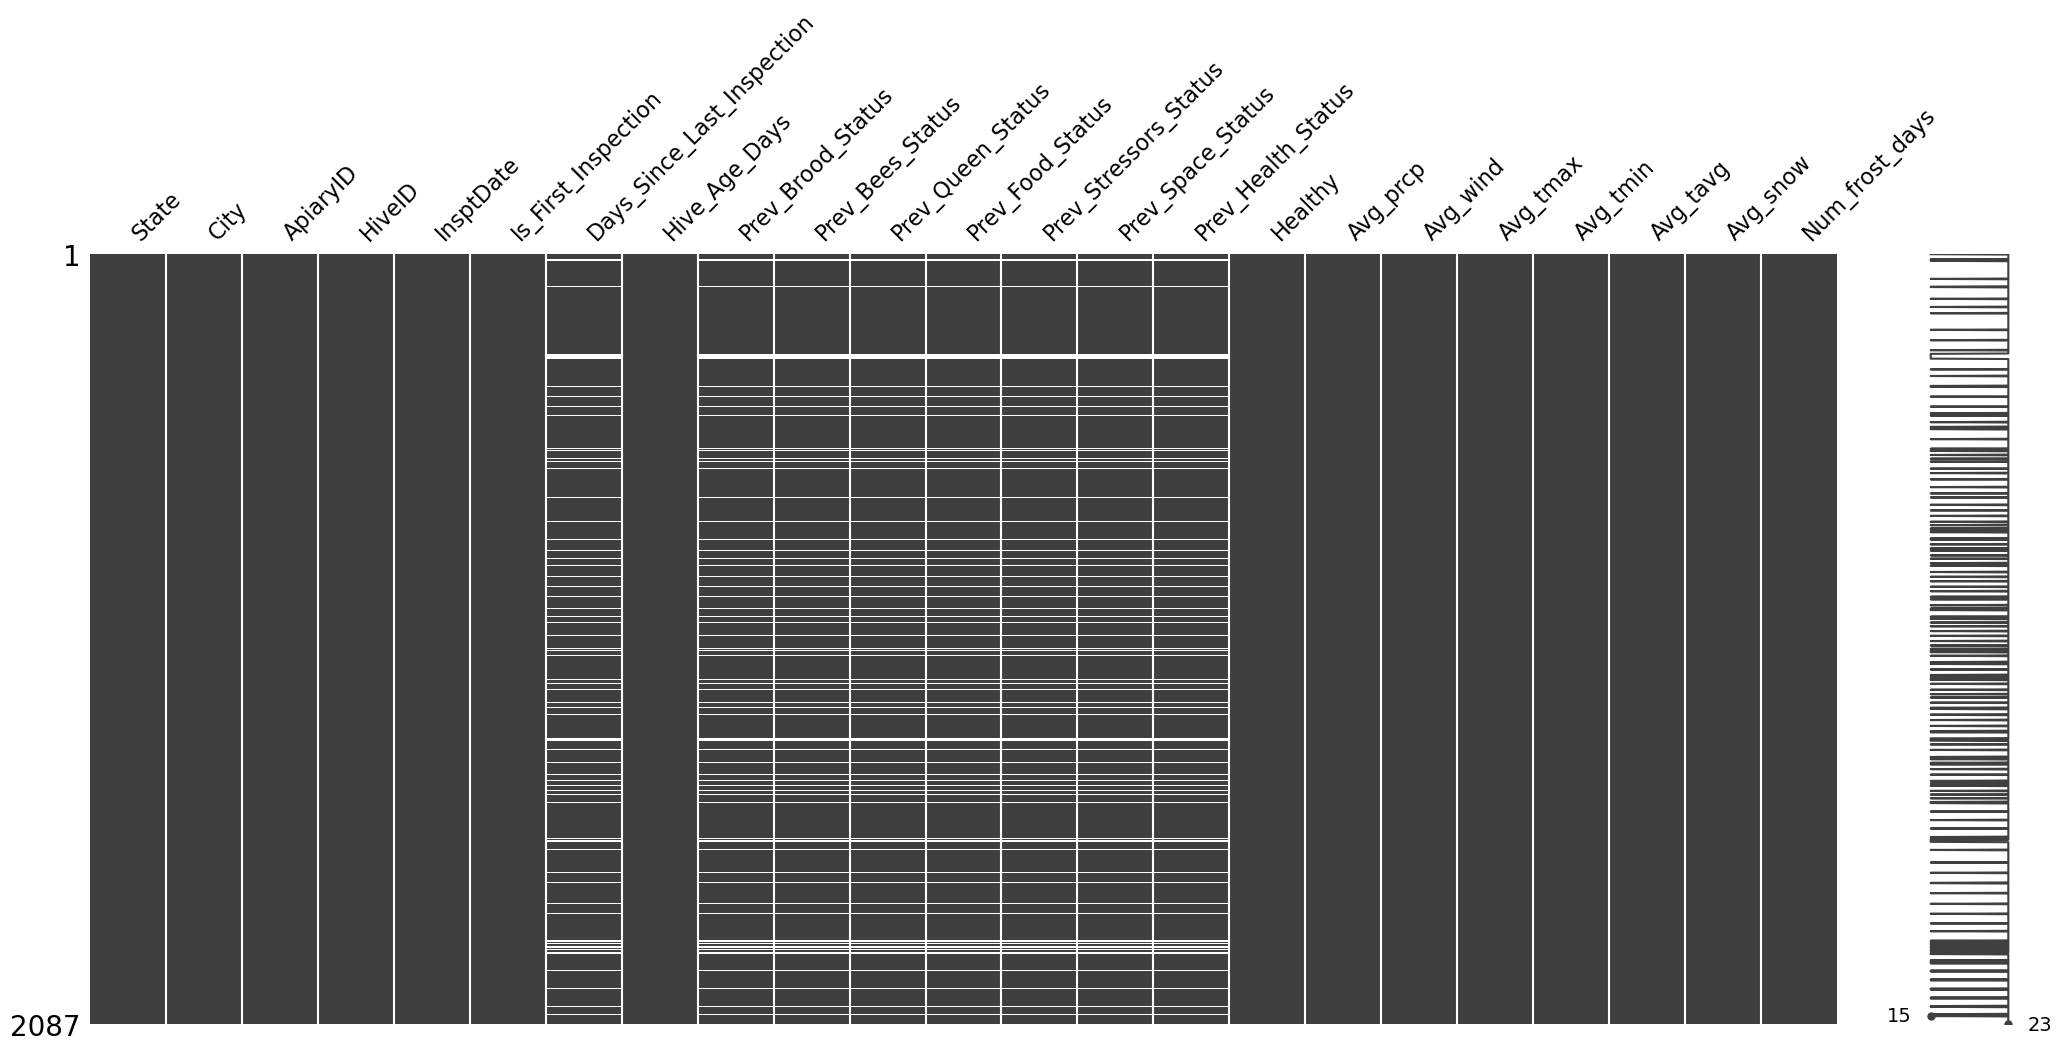

In [ ]:
import missingno as msno
msno.matrix(honeybee_df)
plt.show()

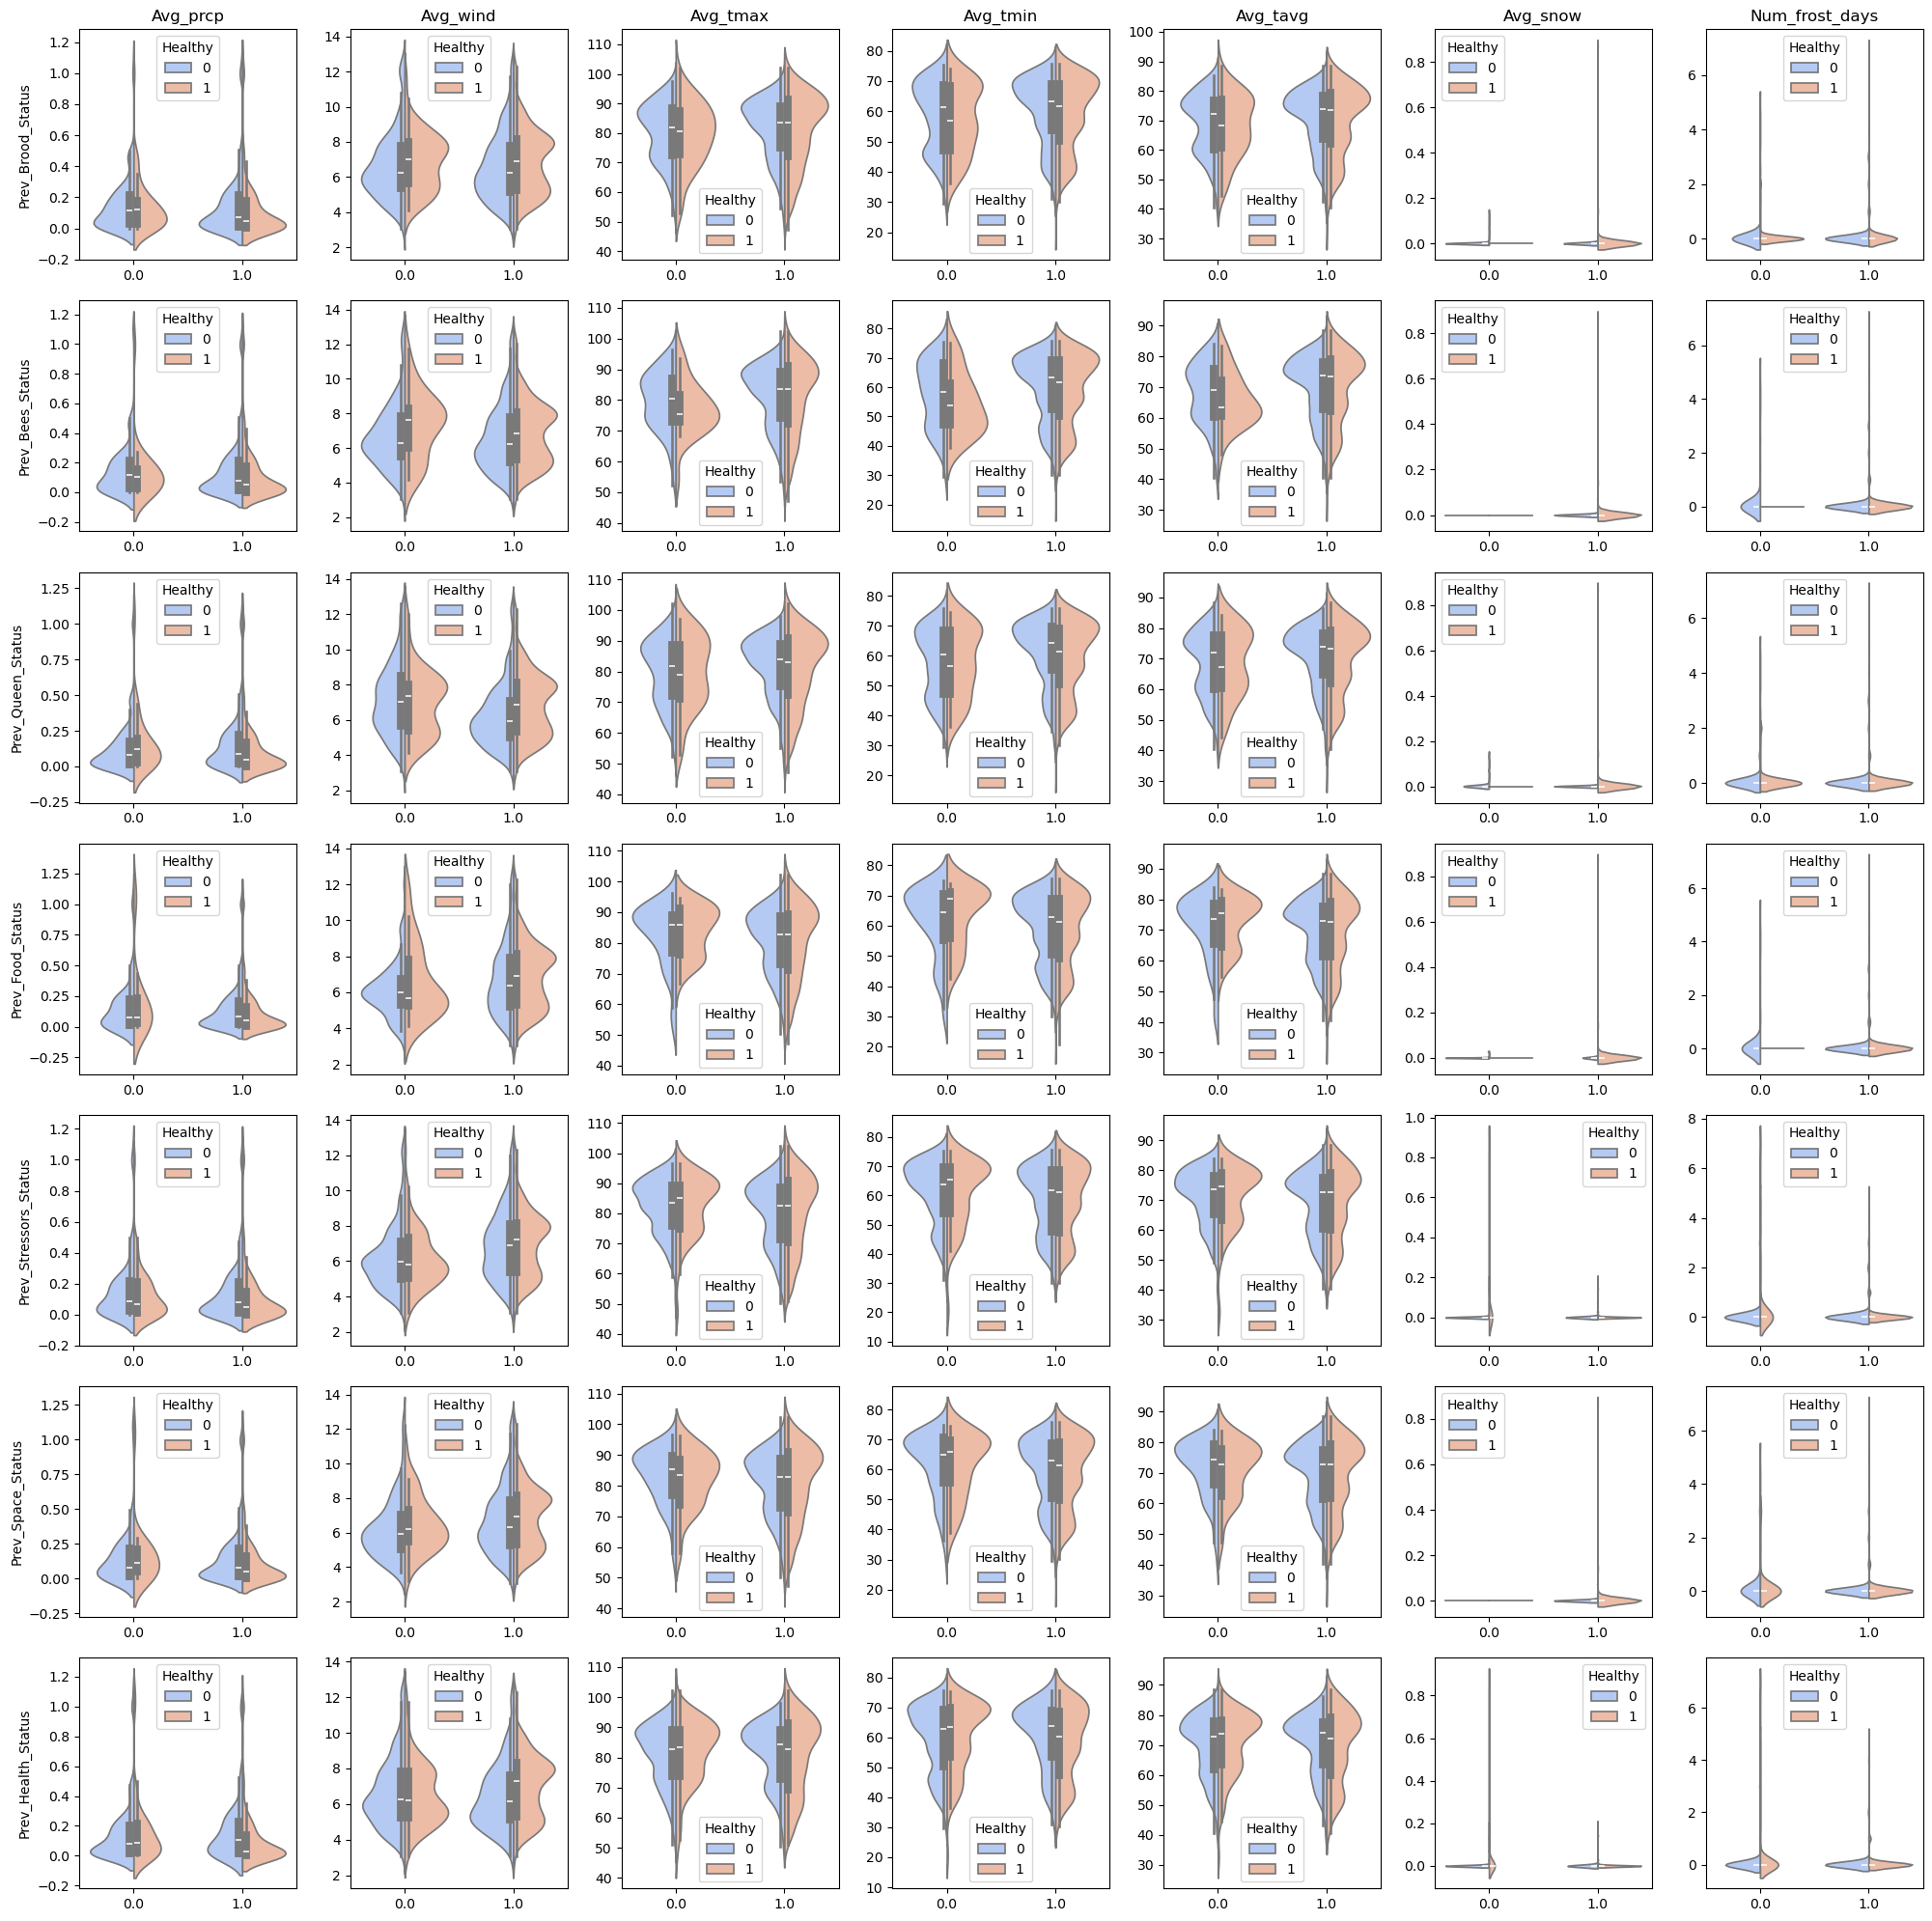

In [109]:
# Lists of variables
env_vars = ['Avg_prcp', 'Avg_wind', 'Avg_tmax', 'Avg_tmin', 'Avg_tavg', 'Avg_snow', 'Num_frost_days']
status_vars = ['Prev_Brood_Status', 'Prev_Bees_Status', 'Prev_Queen_Status', 
               'Prev_Food_Status', 'Prev_Stressors_Status', 'Prev_Space_Status', 'Prev_Health_Status']

# Create a grid of plots
fig, axes = plt.subplots(len(status_vars), len(env_vars), figsize=(20, 20), sharey=False)

for i, status in enumerate(status_vars):
    for j, env in enumerate(env_vars):
        ax = axes[i, j]
        # sns.boxplot(
        #     data=honeybee_df,
        #     x=status, y=env, hue='Healthy',
        #     palette='coolwarm', ax=ax, fliersize=2
        # )
        sns.violinplot(data=honeybee_df, x=status, y=env, hue='Healthy', split=True, palette='coolwarm', ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel('')
        if i == 0:
            ax.set_title(env)
        if j == 0:
            ax.set_ylabel(status)

plt.tight_layout()
plt.show()

/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/3658643952.py:25: UserWarning:

Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations



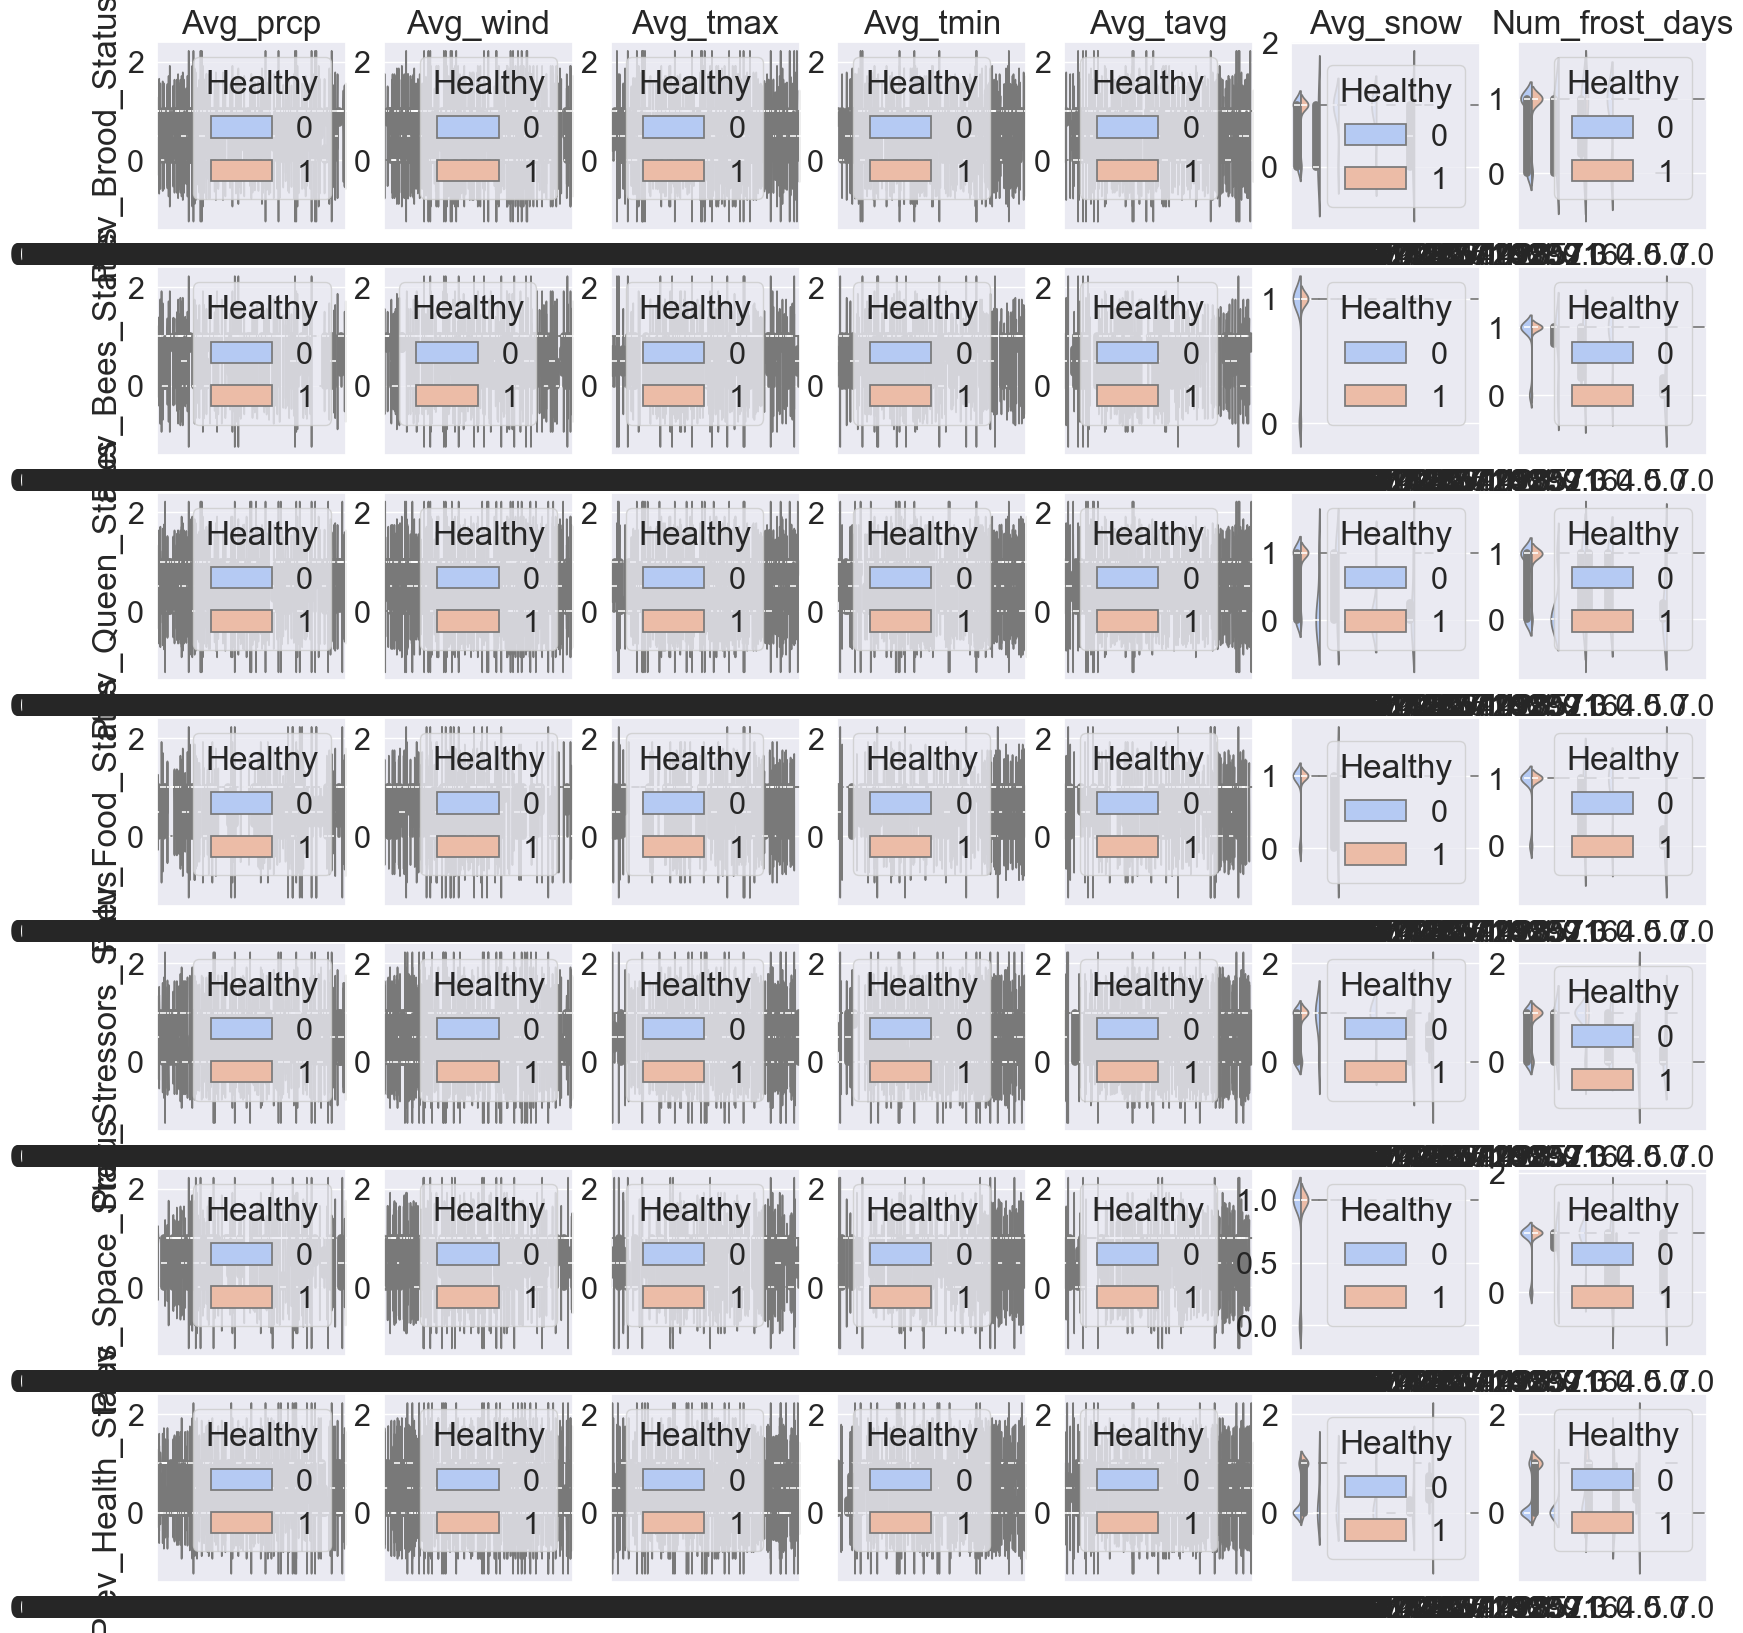

In [148]:
# Lists of variables
env_vars = ['Avg_prcp', 'Avg_wind', 'Avg_tmax', 'Avg_tmin', 'Avg_tavg', 'Avg_snow', 'Num_frost_days']
status_vars = ['Prev_Brood_Status', 'Prev_Bees_Status', 'Prev_Queen_Status', 
               'Prev_Food_Status', 'Prev_Stressors_Status', 'Prev_Space_Status', 'Prev_Health_Status']

# Create a grid of plots
fig, axes = plt.subplots(len(status_vars), len(env_vars), figsize=(20, 20), sharey=False)

for i, status in enumerate(status_vars):
    for j, env in enumerate(env_vars):
        ax = axes[i, j]
        # sns.boxplot(
        #     data=honeybee_df,
        #     x=status, y=env, hue='Healthy',
        #     palette='coolwarm', ax=ax, fliersize=2
        # )
        sns.violinplot(data=honeybee_df, x=env, y=status, hue='Healthy', split=True, palette='coolwarm', ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel('')
        if i == 0:
            ax.set_title(env)
        if j == 0:
            ax.set_ylabel(status)

plt.tight_layout()
plt.show()

There are a few status markers with a value of 0.5. Following the authors of "Predicting Honeybee Health: The Healthy Colony Checklist,Hive Scale and Weather Data" we replace 0.5 with 0. The survey asks for a Yes/No answer. If a clear Yes is not given, we assume that all the criteria for a "Yes" are not fully met, so for consistency we consider the partial yes response to be a "No". 

There are some outliers in frost and snow days. 

In [110]:
honeybee_df['Prev_Brood_Status'] = honeybee_df['Prev_Brood_Status'].replace(0.5, 0)
honeybee_df['Prev_Bees_Status'] = honeybee_df['Prev_Bees_Status'].replace(0.5, 0)
honeybee_df['Prev_Queen_Status'] = honeybee_df['Prev_Queen_Status'].replace(0.5, 0)
honeybee_df['Prev_Stressors_Status'] = honeybee_df['Prev_Stressors_Status'].replace(0.5, 0)
honeybee_df['Prev_Space_Status'] = honeybee_df['Prev_Space_Status'].replace(0.5, 0)


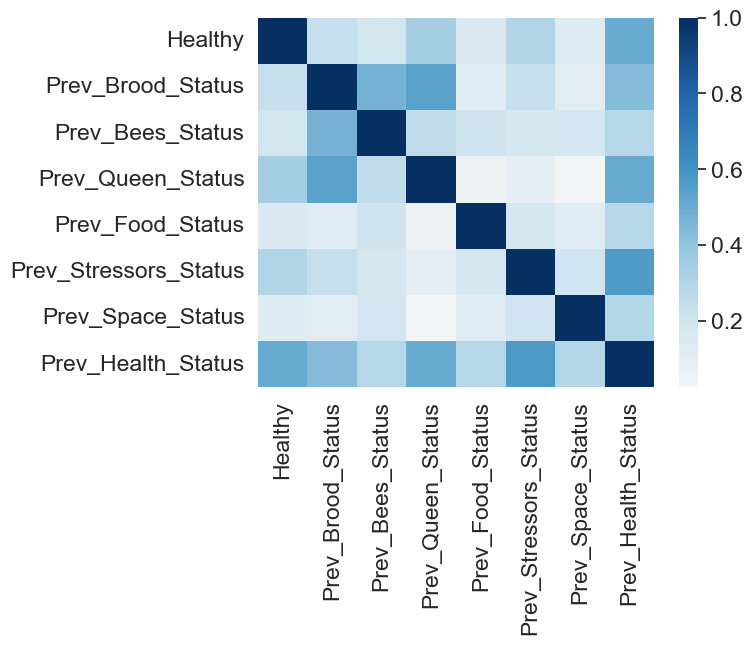

In [145]:

corr_vars = ['Healthy'] + \
             ['Prev_Brood_Status', 'Prev_Bees_Status', 'Prev_Queen_Status',
              'Prev_Food_Status', 'Prev_Stressors_Status', 'Prev_Space_Status',
              'Prev_Health_Status']

corr = honeybee_df[corr_vars].corr()
sns.heatmap(corr, cmap='RdBu', center=0)
# sns.set(font_scale=2) # for presentation 

Previous Health Status has the strongest correlation with whether a hive is healthy now. The correlation between the Previous Health Status and the other status variables is unsuprising since these variables were used to compute the previous health status. The next most correlated variables are Previous Queen Status and Previous Stressor Status. 

Also unsuprising - the Queen status and amount of bees are correlated. 

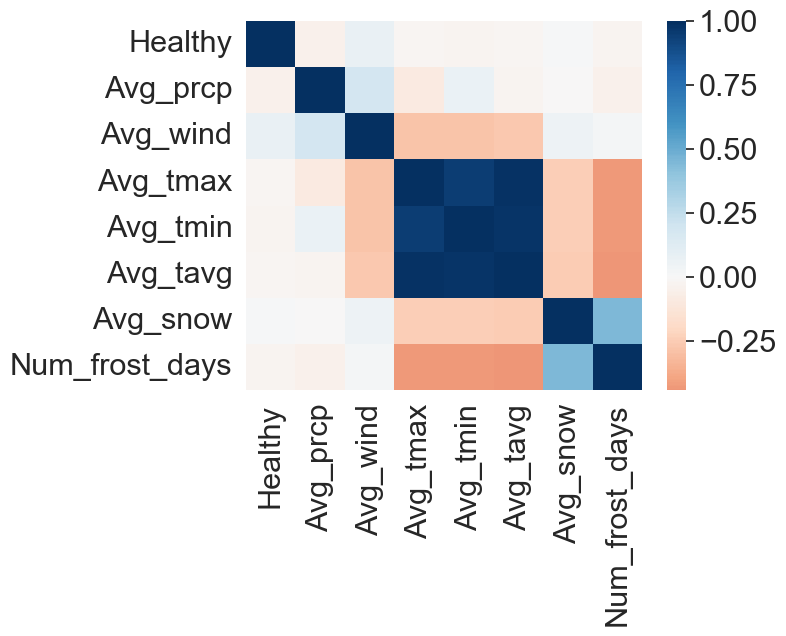

In [147]:

corr_vars = ['Healthy'] + [ 'Avg_prcp', 'Avg_wind', 'Avg_tmax', 'Avg_tmin', 
                           'Avg_tavg', 'Avg_snow', 'Num_frost_days'] 

corr = honeybee_df[corr_vars].corr()
sns.heatmap(corr, cmap='RdBu', center=0)
sns.set(font_scale=2) # for presentation 

There does not seem to be a strong correlation between the weather and the health of the colony. There are some unsuprising correlations in the weather data itself - for example the snow and frost days. 

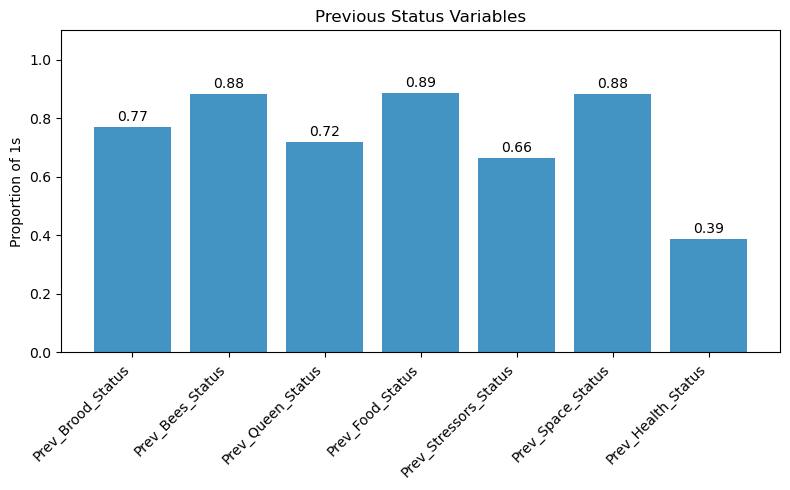

In [143]:
# Compute proportion of 1s for each status variable
counts = []
for var in status_vars:
    data = honeybee_df[var].dropna().astype(int)  # drop NaNs and convert to int
    counts.append(data.mean())  # proportion of 1s

# RdBu coloring: blue for 1s
colors = ['#4393C3'] * len(status_vars)

# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(status_vars, counts, color=colors)

# Add numeric labels on top of each bar
for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)

# Labels and title
plt.ylabel('Proportion of 1s')
plt.title('Previous Status Variables')
plt.ylim(0, 1.1)  # extend y-axis slightly for labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Visualize the transition in Health Status

In [29]:
# Ensure dates are datetime
honeybee_df['InsptDate'] = pd.to_datetime(honeybee_df['InsptDate'])

# Sort by hive and date
honeybee_df = honeybee_df.sort_values(['HiveID', 'InsptDate'])

# Create a shifted column for the next inspection’s health state
honeybee_df['Next_Healthy'] = honeybee_df.groupby('HiveID')['Healthy'].shift(-1)
honeybee_df['Next_Date'] = honeybee_df.groupby('HiveID')['InsptDate'].shift(-1)

# Drop rows where next inspection is missing (last inspection per hive)
transitions = honeybee_df.dropna(subset=['Next_Healthy'])


In [81]:
transition_counts = (
    transitions
    .groupby(['Healthy', 'Next_Healthy'])
    .size()
    .reset_index(name='Count')
)
print(transition_counts)


   Healthy  Next_Healthy  Count
0        0           0.0    870
1        0           1.0    198
2        1           0.0    207
3        1           1.0    474


In [146]:

# Define nodes and links
labels = ['Unhealthy (prev)', 'Healthy (prev)', 'Unhealthy (next)', 'Healthy (next)']

# Map from your transition table to indices in `labels`
label_to_index = {
    (0, 0): (0, 2),
    (0, 1): (0, 3),
    (1, 0): (1, 2),
    (1, 1): (1, 3)
}

sources = []
targets = []
values = []

for _, row in transition_counts.iterrows():
    src, tgt = label_to_index[(int(row['Healthy']), int(row['Next_Healthy']))]
    sources.append(src)
    targets.append(tgt)
    values.append(row['Count'])

# Build Sankey figure
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        label=labels,
        color=['rgba(202,0,32,1)', 'rgba(67,147,195,1)','rgba(202,0,32,1)', 'rgba(67,147,195,1)']  # red=unhealthy, blue=healthy
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=['rgba(202,0,32,0.7)' if s in [0,2] else 'rgba(67,147,195,0.7)' for s in sources]
    )
)])

fig.update_layout(title_text="Hive Health Transitions Between Inspections", font_size=14, width=600)
fig.show()


It appears that the majority of hives that were previously healthy (or unhealthy) remain so at the next inspection with a small portion flipping. Let's investigate the previous status variables through the transition. 

In [91]:
# Ensure no leftover multi-index or duplicate columns
honeybee_df = honeybee_df.copy()
honeybee_df.columns = honeybee_df.columns.map(str)  # ensure no hidden duplicates

# Drop missing values
transitions = honeybee_df.dropna(subset=['Prev_Health_Status', 'Healthy', 'Prev_Brood_Status', 'Prev_Bees_Status', 'Prev_Queen_Status', 
               'Prev_Food_Status', 'Prev_Stressors_Status', 'Prev_Space_Status',]).copy()

# Compute transition probabilities safely
transition_probs_brood = (
    transitions
    .groupby(['Prev_Brood_Status', 'Prev_Health_Status', 'Healthy'], observed=True)
    .size()
    .reset_index(name='Count')  # explicitly name the count column
)

# Normalize within each (Prev_Brood_Status, Prev_Health_Status) group
transition_probs_brood['Probability'] = (
    transition_probs_brood
    .groupby(['Prev_Brood_Status', 'Prev_Health_Status'])['Count']
    .transform(lambda x: x / x.sum())
)

transition_probs_brood.head(6)



,Prev_Brood_Status,Prev_Health_Status,Healthy,Count,Probability
0,0.0,0.0,0,360,0.829493
1,0.0,0.0,1,74,0.170507
2,1.0,0.0,0,581,0.799175
3,1.0,0.0,1,146,0.200825
4,1.0,1.0,0,226,0.305819
5,1.0,1.0,1,513,0.694181


In [92]:
# Compute transition probabilities - Prev_Bees_Status
transition_probs_bees = (
    transitions
    .groupby(['Prev_Bees_Status', 'Prev_Health_Status', 'Healthy'], observed=True)
    .size()
    .reset_index(name='Count')  # explicitly name the count column
)

# Normalize within each (Prev_Bees_Status, Prev_Health_Status) group
transition_probs_bees['Probability'] = (
    transition_probs_bees
    .groupby(['Prev_Bees_Status', 'Prev_Health_Status'])['Count']
    .transform(lambda x: x / x.sum())
)

# Compute transition probabilities - Prev_Queen_Status
transition_probs_queen = (
    transitions
    .groupby(['Prev_Queen_Status', 'Prev_Health_Status', 'Healthy'], observed=True)
    .size()
    .reset_index(name='Count')  # explicitly name the count column
)

# Normalize within each (Prev_Queen_Status, Prev_Health_Status) group
transition_probs_queen['Probability'] = (
    transition_probs_queen
    .groupby(['Prev_Queen_Status', 'Prev_Health_Status'])['Count']
    .transform(lambda x: x / x.sum())
)

# Compute transition probabilities - Prev_Food_Status
transition_probs_food = (
    transitions
    .groupby(['Prev_Food_Status', 'Prev_Health_Status', 'Healthy'], observed=True)
    .size()
    .reset_index(name='Count')  # explicitly name the count column
)

# Normalize within each (Prev_Food_Status, Prev_Health_Status) group
transition_probs_food['Probability'] = (
    transition_probs_food
    .groupby(['Prev_Food_Status', 'Prev_Health_Status'])['Count']
    .transform(lambda x: x / x.sum())
)

# Compute transition probabilities - Prev_Stressors_Status
transition_probs_stressors = (
    transitions
    .groupby(['Prev_Stressors_Status', 'Prev_Health_Status', 'Healthy'], observed=True)
    .size()
    .reset_index(name='Count')  # explicitly name the count column
)

# Normalize within each (Prev_Stressors_Status, Prev_Health_Status) group
transition_probs_stressors['Probability'] = (
    transition_probs_stressors
    .groupby(['Prev_Stressors_Status', 'Prev_Health_Status'])['Count']
    .transform(lambda x: x / x.sum())
)

# Compute transition probabilities - Prev_Space_Status
transition_probs_space = (
    transitions
    .groupby(['Prev_Space_Status', 'Prev_Health_Status', 'Healthy'], observed=True)
    .size()
    .reset_index(name='Count')  # explicitly name the count column
)

# Normalize within each (Prev_Space_Status, Prev_Health_Status) group
transition_probs_space['Probability'] = (
    transition_probs_space
    .groupby(['Prev_Space_Status', 'Prev_Health_Status'])['Count']
    .transform(lambda x: x / x.sum())
)




In [93]:

def plot_transition_heatmap_sankey(df, prev_var, value_col='Count', normalize=True):
    """
    df: DataFrame with columns [prev_var, 'Prev_Health_Status', 'Healthy', 'Count', 'Probability']
    prev_var: string, e.g., 'Prev_Brood_Status'
    value_col: column to use for link widths (Count or Probability)
    normalize: if True, compute probabilities within each prev_var + Prev_Health_Status group
    """
    df = df.copy()
    
    # Normalize to probabilities if requested
    if normalize:
        df['Probability'] = df.groupby([prev_var, 'Prev_Health_Status'])[value_col].transform(lambda x: x / x.sum())
        value_col = 'Probability'
    
    # Inverted RdBu colors for previous variable
    unique_vals = sorted(df[prev_var].dropna().unique())
    if len(unique_vals) == 2:  # binary
        palette = {unique_vals[0]: 'rgb(202,0,32)',  # 0 = red
                   unique_vals[1]: 'rgb(67,147,195)'}  # 1 = blue
    else:
        from plotly.colors import n_colors
        colors = n_colors('rgb(202,0,32)', 'rgb(67,147,195)', len(unique_vals), colortype='rgb')
        palette = {v: c for v, c in zip(unique_vals, colors)}
    
    # Subplots: Heatmap + Sankey
    fig = make_subplots(
        rows=1, cols=2,
        column_widths=[0.5, 0.5],
        specs=[[{"type": "heatmap"}, {"type": "domain"}]],
        subplot_titles=[f"{prev_var} Transition Heatmap", f"{prev_var} Sankey Diagram"]
    )
    
    # --- Heatmap ---
    for val in unique_vals:
        subdf = df[df[prev_var] == val]
        pivot = subdf.pivot(index='Prev_Health_Status', columns='Healthy', values=value_col).fillna(0)
        # Format text labels for each cell
        text_labels = pivot.applymap(lambda x: f"{x:.2f}")
        
        fig.add_trace(
            go.Heatmap(
                z=pivot.values,
                x=['Unhealthy','Healthy'],
                y=['Unhealthy','Healthy'],
                colorscale='RdBu',  # RdBu with 0=red, 1=blue
                showscale=False,    # remove colorbar
                text=text_labels,
                texttemplate="%{text}",
                hovertemplate=f"{prev_var}={val}<br>Prev Health: %{{y}}<br>Current Health: %{{x}}<br>Prob: %{{z:.2f}}<extra></extra>"
            ),
            row=1, col=1
        )
    
    # --- Sankey ---
    labels = ['Prev Unhealthy', 'Prev Healthy', 'Current Unhealthy', 'Current Healthy']
    source, target, value, link_color, customdata = [], [], [], [], []
    
    for _, row in df.iterrows():
        src = 0 if row['Prev_Health_Status'] == 0 else 1
        tgt = 2 if row['Healthy'] == 0 else 3
        source.append(src)
        target.append(tgt)
        value.append(row[value_col])
        customdata.append([row[prev_var]])
        if row[prev_var] == 0:
            link_color.append('rgba(202,0,32,0.7)')  # red, alpha=0.7
        else:
            link_color.append('rgba(67,147,195,0.7)')  # blue, alpha=0.7

    
    fig.add_trace(
        go.Sankey(
            arrangement='snap',
            node=dict(
                pad=20,
                thickness=20,
                label=labels,
                color='rgba(0,0,0,0.3)'
            ),
            link=dict(
                source=source,
                target=target,
                value=value,
                color=link_color,
                customdata=customdata,
                hovertemplate=f"{prev_var}: %{{customdata[0]}}<br>From: %{{source.label}} → To: %{{target.label}}<br>Value: %{{value:.2f}}<extra></extra>"
            )
        ),
        row=1, col=2
    )
    
    # Remove legend
    fig.update_layout(
        title_text=f"Hive Health Transitions by {prev_var} ",
        font=dict(size=12),
        height=500,
        showlegend=False
    )
    
    fig.show()


In [94]:
plot_transition_heatmap_sankey(transition_probs_brood, prev_var='Prev_Brood_Status')
plot_transition_heatmap_sankey(transition_probs_bees, prev_var='Prev_Bees_Status')
plot_transition_heatmap_sankey(transition_probs_queen, prev_var='Prev_Queen_Status')
plot_transition_heatmap_sankey(transition_probs_food, prev_var='Prev_Food_Status')
plot_transition_heatmap_sankey(transition_probs_space, prev_var='Prev_Space_Status')
plot_transition_heatmap_sankey(transition_probs_stressors, prev_var='Prev_Stressors_Status')

/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/p1/dfv0h8rx0ylfp06x8ml2vr_c0000gn/T/ipykernel_17624/2512795094.py:38: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [ ]:
def mosaic_categorical(df, cat_vars=['Prev_Brood_Status', 'Prev_Queen_Status'], target='Healthy'):
    """
    df: DataFrame
    cat_vars: list of previous inspection variables
    target: column to plot proportion for (Healthy)
    """
    import pandas as pd
    
    # Group by categorical variables and target
    group = df.groupby(cat_vars + [target]).size().reset_index(name='Count')
    
    # Pivot to get proportions
    pivot = group.pivot_table(index=cat_vars, columns=target, values='Count', fill_value=0)
    pivot_prop = pivot.div(pivot.sum(axis=1), axis=0)
    
    # Plot as stacked bar chart
    pivot_prop.plot(kind='bar', stacked=True, color=['red','blue'], figsize=(10,5))
    plt.ylabel('Proportion of Hives')
    plt.title(f"Proportion of {target} by {', '.join(cat_vars)}")
    plt.legend(title=target)
    plt.show()

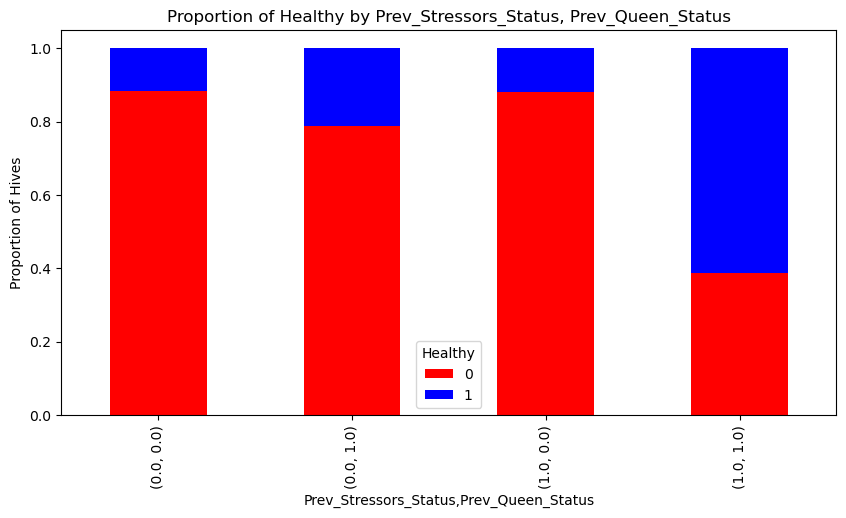

In [111]:
mosaic_categorical(honeybee_df, cat_vars=['Prev_Stressors_Status', 'Prev_Queen_Status'], target='Healthy')
